# 第5章 Matplotlib可视化 · 课堂代码

> 本 notebook 与课件《Python金融数据分析 · 第5章 Matplotlib可视化》配套。
> 内容改编自《Python金融大数据分析（第2版）》第7章。

**使用说明**
- 点击单元格，按 `Shift + Enter` 运行；
- 图形会直接显示在单元格下方。

新增部分为自编教学例子，参考 Wes McKinney《Python for Data Analysis》第3版的主题组织：[在线书](https://wesmckinney.com/book/)。先预测输出，再执行；练习答案可展开查看。

## 路径准备

输入数据放在本章 `data/`，运行生成的文件放在 `outputs/`，Notebook放在 `notebooks/`。下面统一设置路径，Windows和macOS共用；可从本章notebooks目录、本章目录或课程根目录运行。

In [1]:
from pathlib import Path

cwd = Path.cwd()
if cwd.name == "notebooks":
    CHAPTER = cwd.parent
elif cwd.name == "Chapter5 - Matplotlib可视化":
    CHAPTER = cwd
else:
    CHAPTER = cwd / "Chapter5 - Matplotlib可视化"
assert CHAPTER.is_dir(), "请从本章notebooks目录、本章目录或课程根目录运行"
DATA = CHAPTER / "data"
OUTPUTS = CHAPTER / "outputs"
OUTPUTS.mkdir(parents=True, exist_ok=True)


## 0. 数据准备：沿用第4章综合案例

三只模拟股票（茅台、平安、招行）250 个交易日的价格序列。

In [2]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
dates = pd.date_range("2026-01-05", periods=250, freq="B")
rets = pd.DataFrame({
    "茅台": 0.0004 + 0.015 * rng.standard_normal(250),
    "平安": 0.0002 + 0.020 * rng.standard_normal(250),
    "招行": 0.0003 + 0.018 * rng.standard_normal(250)}, index=dates)
prices = 100 * np.exp(rets.cumsum())
prices.tail(3)

,茅台,平安,招行
2026-12-16,89.651397,126.024709,67.261712
2026-12-17,93.681881,121.129685,66.833219
2026-12-18,92.086771,117.584889,65.787109


## 1. Matplotlib基本流程

### 1.1 导入与中文设置

不设置中文字体，图里的汉字会变成方块（"豆腐"）。这两行建议放在每个 notebook 的开头。

In [3]:
import matplotlib.pyplot as plt   # 约定俗成，照抄

# 让图里能显示中文（Windows 用微软雅黑）
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False   # 负号正常显示

### 1.2 画图四步曲

1. `plt.subplots` 建画布和坐标系
2. `ax.plot` 画数据
3. `set_title` / `set_xlabel` / `set_ylabel` / `grid` 装饰
4. 显示（Notebook 中会自动显示）

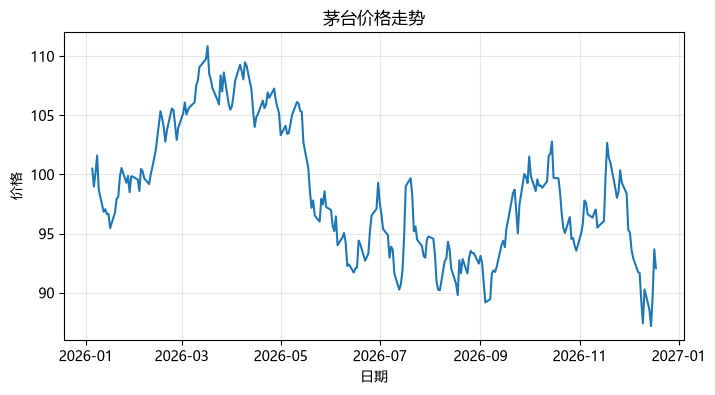

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))  # 1. 建画布和坐标系
ax.plot(prices.index, prices["茅台"])    # 2. 画数据
ax.set_title("茅台价格走势")              # 3. 装饰：标题
ax.set_xlabel("日期")                   #         坐标轴标签
ax.set_ylabel("价格")
ax.grid(alpha=0.3)                      #         网格
plt.show()                              # 4. 显示

### 1.2A 先选图，再写代码

类别比较用柱状图；时间变化用折线图；单变量分布用直方图；两个数值的关系用散点图。先用非金融小表练习同一套绘图接口。

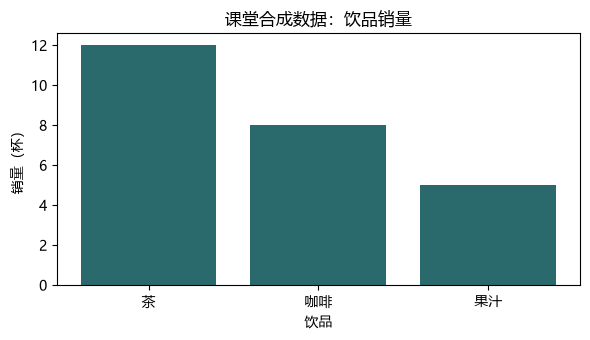

In [5]:
drink_names = ["茶", "咖啡", "果汁"]
drink_counts = [12, 8, 5]
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(drink_names, drink_counts, color="#2B6A6C")
ax.set(title="课堂合成数据：饮品销量", xlabel="饮品", ylabel="销量（杯）")
ax.set_ylim(bottom=0)
fig.tight_layout()
plt.show()

### 1.2B 折线图：横轴需要有顺序

连续五日的气温有时间顺序，适合连线；不能为了让曲线好看先按温度大小排序。所有数值均为教学合成数据。

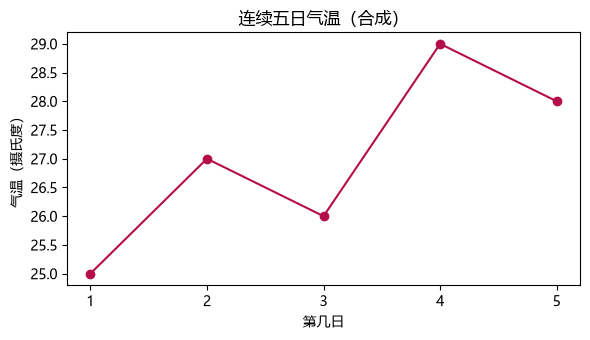

In [6]:
days = [1, 2, 3, 4, 5]
temperature = [25, 27, 26, 29, 28]
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(days, temperature, marker="o", color="#B40D49")
ax.set(title="连续五日气温（合成）", xlabel="第几日", ylabel="气温（摄氏度）")
ax.set_xticks(days)
fig.tight_layout()
plt.show()

**先动手**：在 28 摄氏度画一条虚线并添加图例；为什么折线图不一定要求纵轴从 0 开始？

In [7]:
# 在这里完成练习；参考答案在下一单元格。

<details><summary>参考答案与检查</summary>

```python
ax.axhline(28, linestyle="--", color="gray", label="28摄氏度")
ax.legend()
display(fig)
# 折线图强调变化，可合理缩放，但要保留清晰刻度，不能掩盖幅度。
```
</details>

### 1.3 多条曲线与图例

多次调用 `ax.plot` 即叠加多条曲线；每条线给 `label`，最后 `ax.legend()` 自动生成图例。

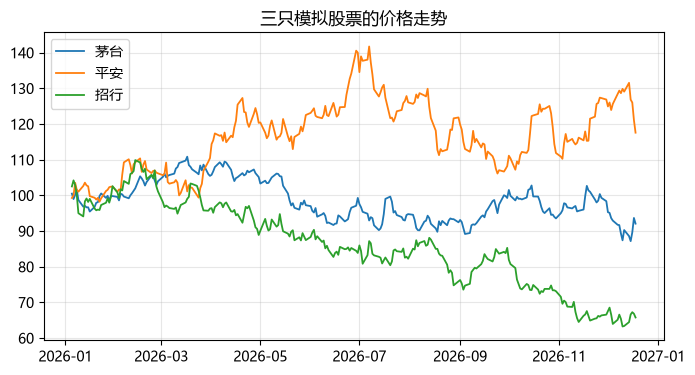

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
for name in prices.columns:                 # 遍历三只股票
    ax.plot(prices.index, prices[name],
            label=name, linewidth=1.3)      # label 供图例使用
ax.set_title("三只模拟股票的价格走势")
ax.legend()          # 显示图例
ax.grid(alpha=0.3)   # 淡网格，alpha 控制透明度

### 1.4 线条样式与保存图片

- `color`：英文名或 `"#B40D49"` 十六进制；
- `linestyle`：实线 `-`、虚线 `--`、点线 `:`；
- `marker`：数据点标记 `o . s ^`。

写报告时**永远用 `savefig` 导出高清图**，不要截图。

Text(0.5, 1.0, '前20个交易日（演示线条样式）')

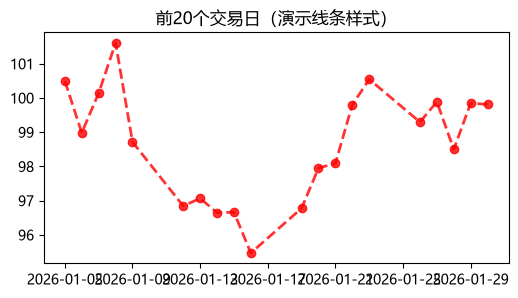

In [9]:
fig, ax = plt.subplots(figsize=(6, 3))
x = prices.index[:20]
y = prices["茅台"].iloc[:20]
ax.plot(x, y,
        color="red",          # 颜色：英文名或 "#B40D49"
        linestyle="--",       # 线型：实线- 虚线-- 点线:
        marker="o",           # 数据点标记：o . s ^
        linewidth=2, alpha=0.8)
ax.set_title("前20个交易日（演示线条样式）")

In [10]:
fig.savefig(OUTPUTS / "prices.png",        # 保存为图片文件
            dpi=300,             # 分辨率（投稿常用300）
            bbox_inches="tight") # 自动裁掉空白边

## 2. 金融常用图表

### 2.1 回撤图：风险"看得见"

`fill_between` 画填充区域——回撤图的经典画法。曲线越"深"，说明从高点跌得越多。

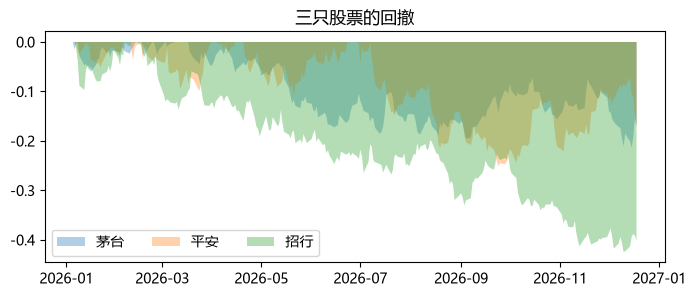

In [11]:
peak = prices.cummax()              # 到每天为止的历史最高价
drawdown = prices / peak - 1        # 回撤（<=0）

fig, ax = plt.subplots(figsize=(8, 3))
for name in drawdown.columns:
    ax.fill_between(drawdown.index, drawdown[name], 0,
                    alpha=0.35, label=name)
ax.set_title("三只股票的回撤")
ax.legend(ncol=3)

### 2.2 子图：把多张图排在一起

`plt.subplots(行数, 列数)` 返回画布和 axes 数组；`tight_layout()` 防止标题重叠。
金融报告常见布局：上价格、下成交量/回撤/波动率。

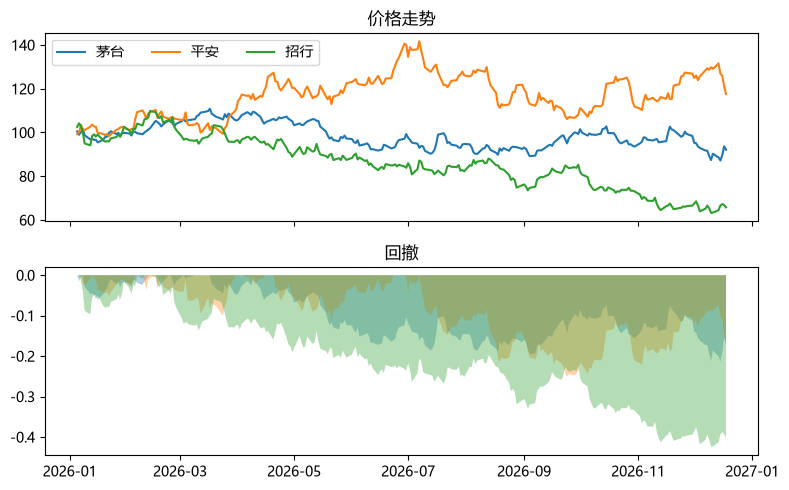

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(8, 5),
                         sharex=True)   # 2行1列，共享x轴
for name in prices.columns:
    axes[0].plot(prices.index, prices[name], label=name)
axes[0].set_title("价格走势")
axes[0].legend(ncol=3)

for name in drawdown.columns:
    axes[1].fill_between(drawdown.index, drawdown[name], 0, alpha=0.35)
axes[1].set_title("回撤")

fig.tight_layout()      # 自动调整间距，防止标题重叠

### 2.3 直方图：收益率长什么样？

- `bins`：分组个数；`density=True`：纵轴变密度，便于与理论分布比较。
- 金融观察：真实收益率往往比正态分布更"厚尾"——极端行情比模型预想的多。

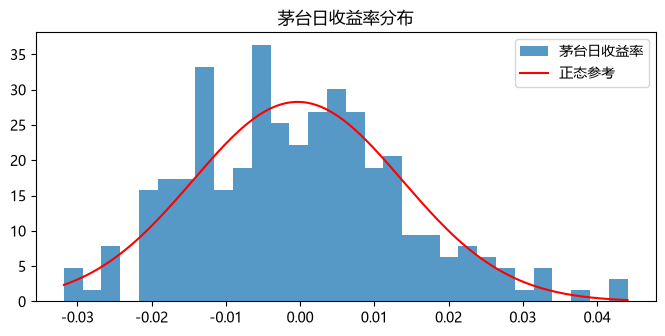

In [13]:
from scipy.stats import norm

r = rets["茅台"].dropna()
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(r, bins=30, density=True,
        alpha=0.75, label="茅台日收益率")

# 正态分布参考线（红色）：两端柱子若高于红线，即为"厚尾"迹象
xx = np.linspace(r.min(), r.max(), 200)
ax.plot(xx, norm.pdf(xx, r.mean(), r.std()),
        color="red", label="正态参考")
ax.set_title("茅台日收益率分布")
ax.legend()

### 2.3A 直方图：每个柱子数什么

合成成绩用于解释分箱：每根柱子数一个分数区间内的学生人数。它与“每班一根柱子”的类别柱状图不同。

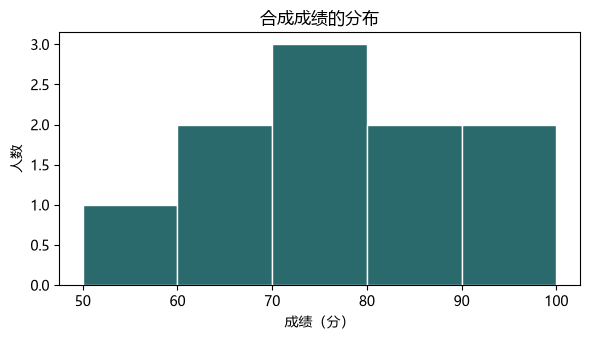

In [14]:
exam_scores = [55, 62, 68, 71, 75, 78, 82, 85, 91, 96]
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(exam_scores, bins=[50, 60, 70, 80, 90, 100],
        edgecolor="white", color="#2B6A6C")
ax.set(title="合成成绩的分布", xlabel="成绩（分）", ylabel="人数")
fig.tight_layout()
plt.show()

### 2.3B 散点图：一行观测对应一个点

每个点代表一名虚构学生。横轴学习时间、纵轴成绩；即使有正向关系，也不能仅凭这张图认定学习时间造成成绩差异。

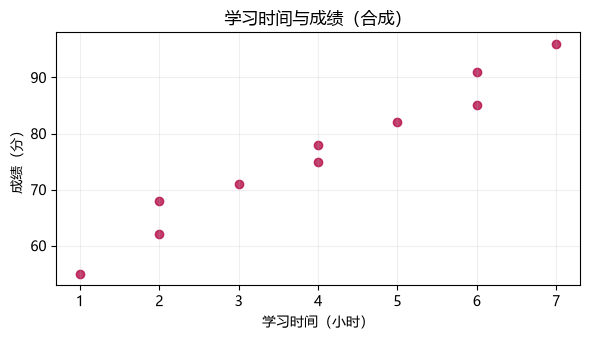

In [15]:
study_hours = [1, 2, 2, 3, 4, 4, 5, 6, 6, 7]
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.scatter(study_hours, exam_scores, alpha=0.8, color="#B40D49")
ax.set(title="学习时间与成绩（合成）", xlabel="学习时间（小时）", ylabel="成绩（分）")
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

### 2.4 柱状图与散点图

- 柱状图适合**少量类别的对比**（各股收益、各行业PE）；
- 散点图越"聚成一条线"，相关性越强——第4章 `corr()` 的图形版。

<Axes: >

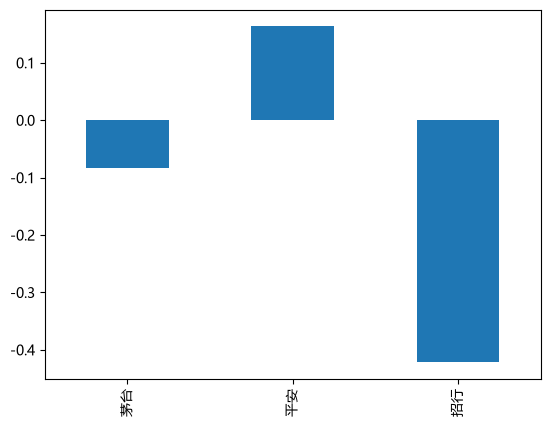

In [16]:
# 柱状图：三只股票的年化平均收益对比
(rets.mean() * 252).plot(kind="bar")

Text(0, 0.5, '招行日收益率')

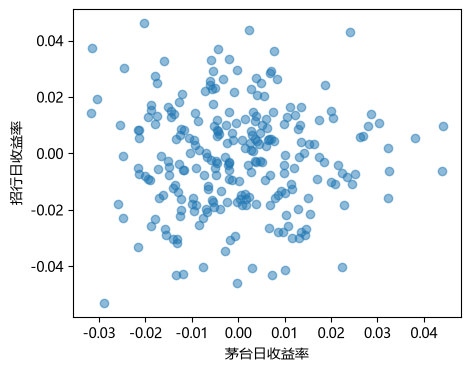

In [17]:
# 散点图：两只股票日收益的联动关系
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(rets["茅台"], rets["招行"], alpha=0.5)
ax.set_xlabel("茅台日收益率")
ax.set_ylabel("招行日收益率")

## 3. pandas快捷绘图

pandas 对 DataFrame/Series 提供 `.plot()`，底层就是 Matplotlib，
自动用列名当图例、日期索引当横轴——探索阶段省时利器。

**分工建议**：探索用 `df.plot()` 快速试；报告用 `plt` 精雕细琢。

<Axes: >

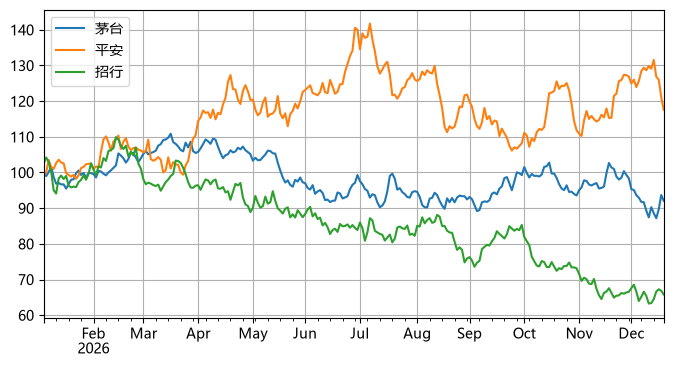

In [18]:
prices.plot(figsize=(8, 4), grid=True)       # 所有列一次画完

<Axes: ylabel='Density'>

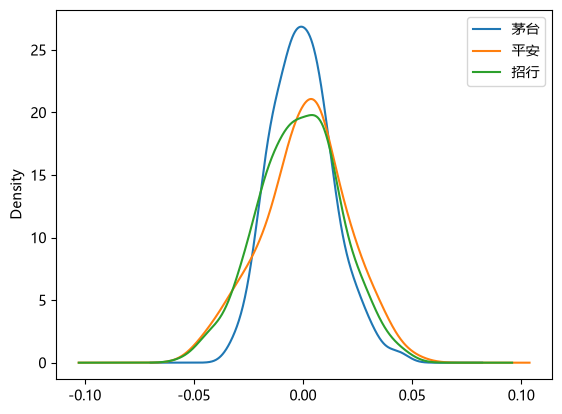

In [19]:
rets.plot(kind="kde")                        # 核密度估计曲线

<Axes: >

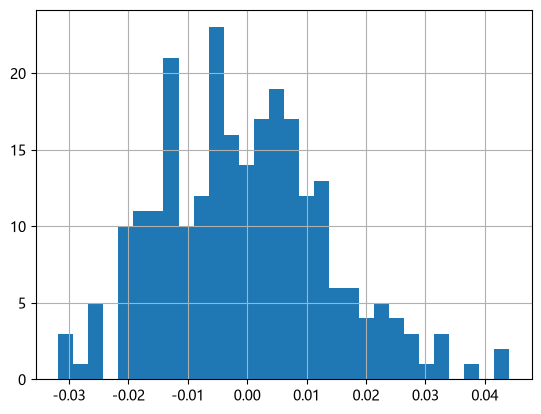

In [20]:
rets["茅台"].hist(bins=30)                   # 单列直方图

### 3A 从计算结果到可读的图

绘图前核对统计口径，绘图后核对标题、单位、样本范围与坐标。柱状图通常从零开始；缺失观测不要随意画成零。

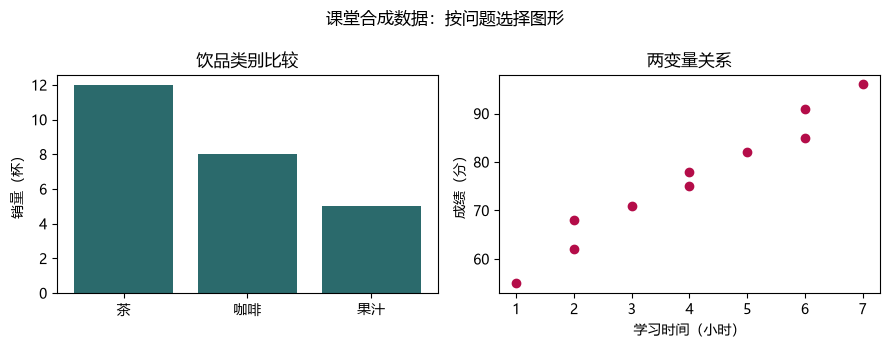

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].bar(drink_names, drink_counts, color="#2B6A6C")
axes[0].set(title="饮品类别比较", ylabel="销量（杯）")
axes[1].scatter(study_hours, exam_scores, color="#B40D49")
axes[1].set(title="两变量关系", xlabel="学习时间（小时）", ylabel="成绩（分）")
fig.suptitle("课堂合成数据：按问题选择图形")
fig.tight_layout()
fig.savefig(OUTPUTS / "nonfinancial_examples.png", dpi=160)
plt.show()

**先动手**：用自己的合成小数据各画一张柱状图和散点图，写一句图能支持的观察，再写一句图不能支持的结论。

In [22]:
# 在这里完成练习；参考答案在下一单元格。

<details><summary>参考答案与检查</summary>

```python
# 示例观察：在给定合成数据中，茶的销量最高（12杯）。
# 不能据此断言：全校学生普遍最喜欢茶；样本并非真实调查。
```
</details>

## 4. 综合案例：一页式分析报告图

四格布局：价格曲线、回撤、收益率分布、散点图。

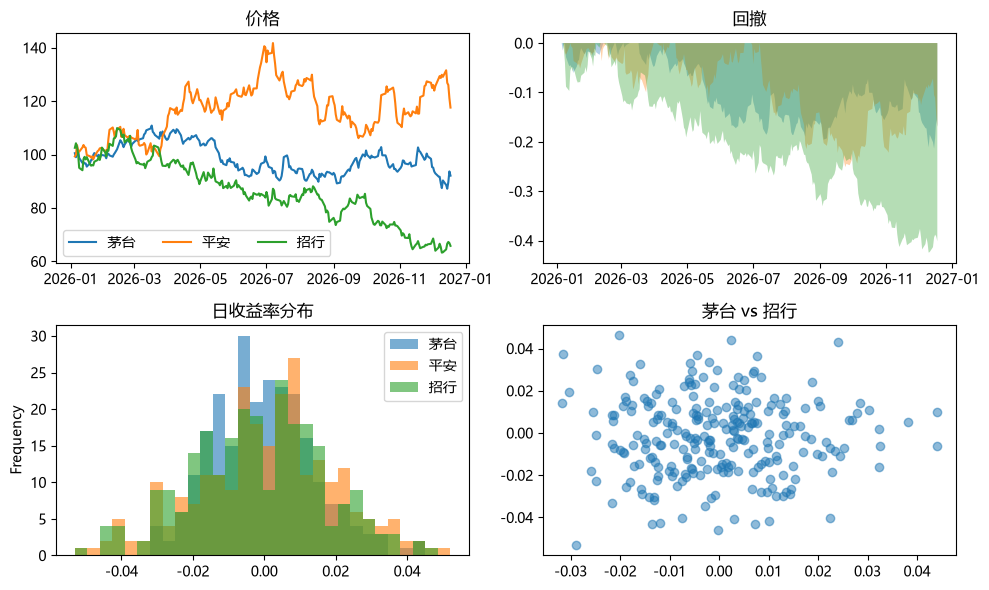

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

# (0,0) 价格曲线
for name in prices.columns:
    axes[0, 0].plot(prices.index, prices[name], label=name)
axes[0, 0].legend(ncol=3); axes[0, 0].set_title("价格")

# (0,1) 回撤
for name in drawdown.columns:
    axes[0, 1].fill_between(drawdown.index, drawdown[name], 0,
                            alpha=0.35)
axes[0, 1].set_title("回撤")

# (1,0) 收益率直方图
rets.plot(kind="hist", bins=30, alpha=0.6, ax=axes[1, 0])
axes[1, 0].set_title("日收益率分布")

# (1,1) 散点图
axes[1, 1].scatter(rets["茅台"], rets["招行"], alpha=0.5)
axes[1, 1].set_title("茅台 vs 招行")

fig.tight_layout()

## 5. 课后练习

1. 复现本章四张图，并用 `savefig` 导出 300 dpi 的 png。
2. 给价格图添加一条水平虚线，标出茅台的期末价格。
3. 选做：把直方图的 `bins` 从 10 改到 60，观察图形变化并思考：bins 太少或太多各有什么问题？

<details>
<summary>练习2 参考答案（点击展开）</summary>

```python
fig, ax = plt.subplots(figsize=(8, 4))
for name in prices.columns:
    ax.plot(prices.index, prices[name], label=name)
ax.axhline(prices["茅台"].iloc[-1], linestyle="--", color="gray")  # 茅台期末价格
ax.set_title("三只模拟股票的价格走势")
ax.legend()
```

</details>

<details>
<summary>练习3 提示（点击展开）</summary>

- bins 太少：分组过粗，分布形状被抹平，看不出厚尾；
- bins 太多：每组样本太少，柱子高低随机跳动，噪声掩盖规律。
- 常用经验：`bins=30` 左右起步，再按数据量微调。

</details>